In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from numpy.typing import ArrayLike
import pandas as pd
from scipy.interpolate import PchipInterpolator, interp1d
from scipy.integrate import trapezoid
from scipy.signal import convolve
from brokenaxes import brokenaxes
from matplotlib.offsetbox import HPacker, VPacker, TextArea, DrawingArea, AnchoredOffsetbox
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch



In [2]:
def gaussian_peak (freqs,amplitude,center,standard_deviation):

    return amplitude/(standard_deviation*np.sqrt(2*np.pi))*np.exp(-(freqs-center)**2/(2*standard_deviation**2))

def model_RIN_spec(freqs, RIN_offset = 10**(-105/10), RIN_offset_high_freq = 10**(-141/10), decay_freq=5.7e5, decay_factor = 1.73e-6, decay_expo =6,  first_rel_osc = [1e3,6e3,8e-7,3e3,0.5e3], second_rel_osc=[1e5,6e5,1.6e-5,4.5e5,0.4e5], first_high_freq=[9.4e5,9.6e5,3e-8,9.5e5,0.4e4], second_high_freq=[1.86e6,1.91e6,8e-10,1.88e6,5e3]):


    freqs_3khz_min = first_rel_osc[0]
    freqs_3khz_max = first_rel_osc[1]
    amp_3khz = first_rel_osc[2]
    center_3khz = first_rel_osc[3]
    std_3khz = first_rel_osc[4]

    freqs_500khz_min = second_rel_osc[0]
    freqs_500khz_max = second_rel_osc[1]
    amp_500khz = second_rel_osc[2]
    center_500khz = second_rel_osc[3]
    std_500khz = second_rel_osc[4]

    freqs_900khz_min = first_high_freq[0]
    freqs_900khz_max = first_high_freq[1]
    amp_900khz = first_high_freq[2]
    center_900khz = first_high_freq[3]
    std_900khz = first_high_freq[4]

    freqs_1800khz_min = second_high_freq[0]
    freqs_1800khz_max = second_high_freq[1]
    amp_1800khz = second_high_freq[2]
    center_1800khz = second_high_freq[3]
    std_1800khz = second_high_freq[4]



    freqs_decay = freqs[(freqs > decay_freq)]
    
    rin_spectrum = np.zeros_like(freqs) + RIN_offset

    rin_spectrum[(freqs > decay_freq)] = RIN_offset/(freqs_decay*decay_factor)**decay_expo + RIN_offset_high_freq

    
    freqs_3khz =  freqs[(freqs >= freqs_3khz_min) & (freqs <= freqs_3khz_max)]
    freqs_500khz =  freqs[(freqs >= freqs_500khz_min) & (freqs <= freqs_500khz_max)]
    freqs_900khz = freqs[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)]
    freqs_1800khz = freqs[(freqs >= freqs_1800khz_min) & (freqs <= freqs_1800khz_max)]


    rin_spectrum[(freqs >= freqs_3khz_min) & (freqs <= freqs_3khz_max)] += gaussian_peak(freqs_3khz,amp_3khz,center_3khz,std_3khz)

    rin_spectrum[(freqs >= freqs_500khz_min) & (freqs <= freqs_500khz_max)] += gaussian_peak(freqs_500khz,amp_500khz,center_500khz,std_500khz)

    rin_spectrum[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)] += gaussian_peak(freqs_900khz,amp_900khz,center_900khz,std_900khz)

    rin_spectrum[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)] += gaussian_peak(freqs_900khz,amp_900khz,center_900khz,std_900khz)
    
    rin_spectrum[(freqs >= freqs_1800khz_min) & (freqs <= freqs_1800khz_max)] += gaussian_peak(freqs_1800khz,amp_1800khz,center_1800khz,std_1800khz)

    return rin_spectrum


In [3]:
def dB_to_linear(RIN_dB: ArrayLike):

    return 10**(RIN_dB/10)


def linear_to_dB(RIN_lin: ArrayLike):
    
    return 10*np.log10(RIN_lin)

def conv_term(frequencies,RIN_1_lin,RIN_2_lin):
    
    df = frequencies[10] - frequencies[9]

    conv_spec = convolve(RIN_1_lin,RIN_2_lin)*df #Convolve is a discrete sum. Needs to multiply with spacing. (Here spacing is 1 Hz)
    

    conv_freq = 2*frequencies[0] + df * np.arange(len(conv_spec))

    conv_lin_grid = conv_spec[(conv_freq<=frequencies[-1])]

    conv_on_orig_grid = np.zeros_like(RIN_1_lin)

    N_fix = int(frequencies[0]/df+1)

    conv_on_orig_grid[int(N_fix):] = conv_lin_grid

    return conv_on_orig_grid


def conv2_term(frequencies,RIN_1_lin,RIN_2_lin,RIN_3_lin):

    df = frequencies[10] - frequencies[9]

    conv2_spec = convolve(convolve(RIN_1_lin,RIN_2_lin)*df, RIN_3_lin)*df #Convolve is a discrete sum. Needs to multiply with spacing. (Here spacing is 1 Hz)


    conv2_freq = 4*frequencies[0] + df * np.arange(len(conv2_spec))


    conv_lin_grid = conv2_spec[(conv2_freq<=frequencies[-1])]

    conv_on_orig_grid = np.zeros_like(RIN_1_lin)

    N_fix = int((4*frequencies[0]-frequencies[0])/df+1)

    conv_on_orig_grid[int(N_fix):] = conv_lin_grid

    return conv_on_orig_grid



def integrated_RIN(freqs: ArrayLike, RIN_lin: ArrayLike):

    int_RIN_lin = trapezoid(x=freqs,y=RIN_lin)

    return int_RIN_lin


def SHG_RIN_spec(frequencies:ArrayLike,RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in 1/Hz

    RIN_lin = RIN_pump


    conv_on_orig_grid = conv_term(frequencies,RIN_lin,RIN_lin)
    
    SHG_RIN_lin = 4*RIN_lin + 2 * conv_on_orig_grid

    return SHG_RIN_lin


def approx_SHG_RIN_spec(RIN_pump: ArrayLike): #Approximate SHG RIN. Input and output RIN is in 1/Hz

    RIN_lin = RIN_pump

    SHG_RIN_lin = 4*RIN_lin

    return SHG_RIN_lin


def SFG_RIN_spec(frequencies:ArrayLike, RIN_pump_1: ArrayLike, RIN_pump_2: ArrayLike): #reduced RIN (Isserlis' theorem applied) for completely uncorrelated pumps. Input and output RIN is in 1/Hz

    RIN_lin_1 = RIN_pump_1
    RIN_lin_2 = RIN_pump_2

    
    conv_on_orig_grid = conv_term(frequencies,RIN_lin_1,RIN_lin_2)
  
    SFG_RIN_lin = RIN_lin_1 + RIN_lin_2 + conv_on_orig_grid

    return SFG_RIN_lin


# def cascaded_RIN_spec(freqs: ArrayLike, RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

#     RIN_lin = dB_to_linear(RIN_pump)

#     RIN_int = trapezoid(x=freqs,y=RIN_lin)

#     cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* convolve(RIN_lin,RIN_lin) + 6* convolve(convolve(RIN_lin,RIN_lin),RIN_lin)

#     return linear_to_dB(cascaded_RIN_lin)


def THG_RIN_spec(freqs: ArrayLike, RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in 1/Hz

    RIN_lin = RIN_pump

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    conv_on_orig_grid = conv_term(freqs, RIN_lin,RIN_lin)


    conv2_on_orig_grid = conv2_term(freqs,RIN_lin,RIN_lin,RIN_lin)

 
    cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* conv_on_orig_grid + 6* conv2_on_orig_grid


    return cascaded_RIN_lin


def approx_THG_RIN_spec(RIN_pump: ArrayLike):
    
    RIN_THG = RIN_pump*9

    return RIN_THG


def THG_RIN_spec_var(freqs, RIN_pump: ArrayLike, RIN_int_dB: float): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in 1/Hz

    RIN_lin = RIN_pump

    RIN_int = RIN_int_dB

    # RIN_int = var # variance/1mW^2 such that we get the integrated RIN value 

    conv_on_orig_grid = conv_term(freqs, RIN_lin,RIN_lin)


    conv2_on_orig_grid = conv2_term(freqs,RIN_lin,RIN_lin,RIN_lin)

 
    cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* conv_on_orig_grid + 6* conv2_on_orig_grid


    return cascaded_RIN_lin


### Terms comparison

def RIN_squared(frequencies: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    conv_on_orig_grid = conv_term(frequencies, RIN_lin,RIN_lin)


    RIN_sq = conv_on_orig_grid

    return RIN_sq

    
def RIN_tripled(frequencies:ArrayLike,RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    conv2_on_orig_grid = conv2_term(frequencies,RIN_lin,RIN_lin,RIN_lin)


    RIN_tri = conv2_on_orig_grid

    return RIN_tri
    

def variance_offset(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return RIN_int

    
def variance_squared_offset(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return RIN_int**2


def RIN_variance(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return RIN_lin*RIN_int
    

def RIN_variance_squared(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = RIN_pump

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return RIN_lin*RIN_int**2


In [4]:
def interpolation_back_on_orig_grid(f_start,f_end,f_log_input,f_log_output, RIN_log, N_lin):
    # 1. uniform linear grid
    f_lin = np.linspace(f_start, f_end, N_lin)

    # 2. interpolate RIN onto linear grid
    interp_RIN = PchipInterpolator(f_log_input, RIN_log)
    RIN_lin = interp_RIN(f_lin)

    # 3. restrict convolution to original spectrum
    interp_log = interp1d(
        f_lin, RIN_lin,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    lin_on_orig = interp_log(f_log_output)

    return lin_on_orig



def self_convolution_on_orig_grid(f_start,f_end,f_log_input,f_log_output, RIN_log, N_lin):
    # 1. uniform linear grid
    f_lin = np.linspace(f_start, f_end, N_lin)
    df = f_lin[1] - f_lin[0]

    # 2. interpolate RIN onto linear grid
    interp_RIN = PchipInterpolator(f_log_input, RIN_log)
    RIN_lin = interp_RIN(f_lin)

    # 3. FFT self-convolution
    H_full = convolve(RIN_lin, RIN_lin, mode='full') * df
    f_H = np.linspace(2*f_lin[0], 2*f_lin[-1], len(H_full))

    # 4. restrict convolution to output log grid spectrum
    interp_H = interp1d(
        f_H, H_full,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    H_on_orig = interp_H(f_log_output)

    return H_on_orig


def rel_rms_error(S_ref, S):
    num = np.sqrt(np.mean((S_ref - S)**2))

    den = np.sqrt(np.mean(S_ref**2))

    return num/den

def rms_rel_error(S_ref, S):

    sre = 0

    for i in range(len(S_ref)):


        if S_ref[i] != 0:
            sre += ((S[i] - S_ref[i])/S_ref[i])**2 
        # else
        #     msre += 0

    rmsre = np.sqrt(sre / len(S_ref))

    return rmsre

In [5]:
#Loading data, converting to linear y-values and interpolate to a linear grid (in order to do convolution)

f_start = 1e3
f_end = 1e7
N_points = int(1e7-1e3)

frequencies_log_raw = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))
frequencies_log = frequencies_log_raw[( (frequencies_log_raw>= f_start ) & (frequencies_log_raw<= f_end))]

frequencies_lin = np.linspace(f_start,f_end,N_points)

folder = r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Frequency conversion RIN and FN\Pertoldi\plotting+data\plotting+data\\"

filename = 'THG RIN spectra.xlsx'
file_path = folder + filename

#THG
df698_RIN = pd.read_excel(file_path,  sheet_name='698nm DC, G=1')
Freq_THG698 = df698_RIN.iloc[:,0]
RIN_THG698_raw = dB_to_linear(df698_RIN.iloc[:,1])


# Create an interpolation function
interp_func = PchipInterpolator(Freq_THG698, RIN_THG698_raw)
# Use this function to interpolate your data to match the new frequencies vector
RIN698THG_log = interp_func(frequencies_log)
RIN698THG_lin = interp_func(frequencies_lin)

THG_freqs = frequencies_log
THG_RIN = RIN698THG_log


#Pump
df2095_RIN = pd.read_excel(file_path,  sheet_name='2095nm + amp1 + amp2, AC') 
Freq_2095 = df2095_RIN.iloc[:,0]
RIN_2095_raw = dB_to_linear(df2095_RIN.iloc[:,1])

# Create an interpolation function
interp_func = PchipInterpolator(Freq_2095, RIN_2095_raw)
# Use this function to interpolate your data to match the new frequencies vector
RIN2095_log = interp_func(frequencies_log)
RIN2095_lin = interp_func(frequencies_lin)

pump_freqs = frequencies_log
pump_RIN = RIN2095_log
pump_RIN_lin = RIN2095_lin


#SHG
filename = f'1045 rin 0{2}'
df1047 = pd.read_csv(folder + filename, sep = '\t', header = None)
Freq_SHG1047 = df1047.iloc[:, 0]
RIN_SHG1047_raw = dB_to_linear(df1047.iloc[:,1 ])
    
# Create an interpolation function
interp_func = PchipInterpolator(Freq_SHG1047, RIN_SHG1047_raw) # interpolate.interp1d(freq, RIN, kind='linear', fill_value='extrapolate')
# Use this function to interpolate your data to match the new frequencies vector
RIN1047SHG_log = interp_func(frequencies_log)
RIN1047SHG_lin = interp_func(frequencies_lin)

SHG_freqs = frequencies_log
SHG_RIN = RIN1047SHG_log



# SFG DATA 
#Pump2
filename = 'RIN_DORY1970_698nm500mW.txt' # 500, 600, 700, 800 

df1970 = pd.read_csv(folder + filename, sep = '\t', header = None)
Freq_1970 = df1970.iloc[:, 0]
RIN_1970_raw = dB_to_linear(df1970.iloc[:,1 ])
    
# Create an interpolation function
interp_func = PchipInterpolator(Freq_1970, RIN_1970_raw)
# Use this function to interpolate your data to match the new frequencies vector
RIN1970_log = interp_func(frequencies_log)
RIN1970_lin = interp_func(frequencies_lin)

SFG_pump2_freqs = frequencies_log
SFG_pump2_RIN = RIN1970_log



#Pump1
filename = 'RIN_DORY1082nm250mW400mA.txt' #, 277 400

df1082 = pd.read_csv(folder + filename, sep = '\t', header = None)
Freq_1082 = df1082.iloc[:, 0]
RIN_1082_raw = dB_to_linear(df1082.iloc[:,1 ])
    
# Create an interpolation function
interp_func = PchipInterpolator(Freq_1082, RIN_1082_raw)
# Use this function to interpolate your data to match the new frequencies vector
RIN1082_log = interp_func(frequencies_log)
RIN1082_lin = interp_func(frequencies_lin)

SFG_pump1_freqs = frequencies_log
SFG_pump1_RIN = RIN1082_log



# RIN_sum_lin = 10**(RIN1082/10) + 10**(RIN1970/10)
# RIN_sum_SFG = 10*np.log10(RIN_sum_lin)


filename = 'RIN_SFG698_250mW1082_400mW1970.txt'  

df698SFG = pd.read_csv(folder + filename, sep = '\t', header = None)
Freq_SFG698 = df698SFG.iloc[:, 0]
RIN_SFG_698_raw = dB_to_linear(df698SFG.iloc[:,1 ])
    
# Create an interpolation function
interp_func = PchipInterpolator(Freq_SFG698, RIN_SFG_698_raw)
# Use this function to interpolate your data to match the new frequencies vector
RIN698SFG_log = interp_func(frequencies_log)
RIN698SFG_lin = interp_func(frequencies_lin)

SFG_freqs = frequencies_log
SFG_RIN = RIN698SFG_log



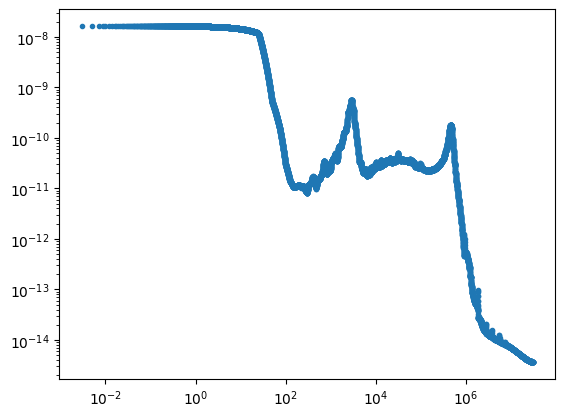

In [6]:
plt.plot(Freq_2095,RIN_2095_raw,'.')
plt.xscale('log')
plt.yscale('log')

In [7]:
#Convergence test

f_start = 1e3

N_lin = [1e3,1e4,1e5,1e6,1e7,1e8]

interp_results = []

conv_results = []

RIN_2095_raw_plot_range = RIN_2095_raw[((Freq_2095 >= f_start) & (Freq_2095<=f_end))]

Freq_2095_plot_range = Freq_2095[((Freq_2095 >= f_start) & (Freq_2095<=f_end))]


RIN_log = RIN_2095_raw_plot_range #model_RIN_spec(Freq_2095)

for N in N_lin:
    
    interp_back = interpolation_back_on_orig_grid(f_start,f_end,Freq_2095_plot_range,frequencies_log,RIN_log,int(N)) #Doing linear interpolation and then back onto input grid
    interp_results.append(interp_back)

    conv = self_convolution_on_orig_grid(f_start,f_end,Freq_2095_plot_range,frequencies_log,RIN_log,int(N)) #Linear interpolation of input --> taking convolution --> interpolation back to input grid

    conv_results.append(conv)


interp_ref = RIN2095_log #model_RIN_spec(frequencies_log)
conv_ref = conv_results[-1]

rel_error_interp = []
rel_error_conv = []
rel_step_error_conv =[]


rel_rms_error_interp = []
rel_rms_error_conv = []

rms_rel_error_interp = []
rms_rel_error_conv = []



for i in range(len(N_lin)):
    err_interp = np.max (np.abs (np.abs( interp_results[i]-interp_ref) / interp_ref) )
    rel_error_interp.append(err_interp)

    rrmse = rel_rms_error(interp_ref,interp_results[i])
    rmsre = rms_rel_error(interp_ref,interp_results[i])

    rel_rms_error_interp.append(rrmse)
    rms_rel_error_interp.append(rmsre)


for i in range(len(N_lin)-1):
    err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_ref) / conv_ref) )
    step_err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_results[i+1]) / conv_results[i+1]) )

    rel_error_conv.append(err_conv)
    rel_step_error_conv.append(step_err_conv)


    rrmse = rel_rms_error(conv_results[i+1],conv_results[i])
    rmsre = rms_rel_error(conv_results[i+1],conv_results[i])

    rel_rms_error_conv.append(rrmse)
    rms_rel_error_conv.append(rmsre)



KeyboardInterrupt: 

In [ ]:
#Convergence test

# N_lin = [1e3,1e4,1e5,1e6,1e7,1e8]

# interp_results_lrange = []

# conv_results_lrange = [] #Larger range of frequencies than shown in plot in article

# f_start = 1e1

# RIN_2095_raw_lrange = RIN_2095_raw[((Freq_2095 >= f_start) & (Freq_2095<= f_end))]
# Freq_2095_lrange = Freq_2095[((Freq_2095 >= f_start) & (Freq_2095<=f_end))]


# RIN_log = RIN_2095_raw_lrange #model_RIN_spec(Freq_2095)

# for N in N_lin:
    
#     interp_back = interpolation_back_on_orig_grid(f_start,f_end,Freq_2095_lrange,frequencies_log,RIN_log,int(N)) #Doing linear interpolation and then back onto input grid
#     interp_results_lrange.append(interp_back)

#     conv = self_convolution_on_orig_grid(f_start,f_end,Freq_2095_lrange,frequencies_log,RIN_log,int(N)) #Linear interpolation of input --> taking convolution --> interpolation to output grid

#     conv_results_lrange.append(conv)


# interp_ref = RIN2095_log # model_RIN_spec(frequencies_log)
# conv_ref = conv_results_lrange[-1]

# rel_error_interp_lrange = []
# rel_error_conv_lrange = []
# rel_step_error_conv_lrange =[]


# rel_rms_error_interp_lrange = []
# rel_rms_error_conv_lrange = []

# rms_rel_error_interp_lrange = []
# rms_rel_error_conv_lrange = []



# for i in range(len(N_lin)):
#     err_interp = np.max (np.abs (np.abs( interp_results_lrange[i]-interp_ref) / interp_ref) )
#     rel_error_interp_lrange.append(err_interp)

#     rrmse = rel_rms_error(interp_ref,interp_results_lrange[i])
#     rmsre = rms_rel_error(interp_ref,interp_results_lrange[i])

#     rel_rms_error_interp_lrange.append(rrmse)
#     rms_rel_error_interp_lrange.append(rmsre)


# for i in range(len(N_lin)-1):
#     err_conv = np.nanmax (np.abs (np.abs( conv_results_lrange[i]-conv_ref) / conv_ref) )
#     step_err_conv = np.nanmax (np.abs (np.abs( conv_results_lrange[i]-conv_results_lrange[i+1]) / conv_results_lrange[i+1]) )

#     rel_error_conv_lrange.append(err_conv)
#     rel_step_error_conv_lrange.append(step_err_conv)


#     rrmse = rel_rms_error(conv_results_lrange[i+1],conv_results_lrange[i])
#     rmsre = rms_rel_error(conv_results_lrange[i+1],conv_results_lrange[i])

#     rel_rms_error_conv_lrange.append(rrmse)
#     rms_rel_error_conv_lrange.append(rmsre)



In [ ]:
# colors = ['tab:orange','tab:blue', 'tab:green', 'tab:red', 'tab:brown', 'tab:gray']

# for i,N in enumerate(N_lin):

#     plt.plot(frequencies_log, conv_results[i],'--',color = colors[i],label=f'1e3 conv, {N:.0e} lin grid points')
#     plt.plot(frequencies_log, conv_results_lrange[i],'-',color = colors[i],label=f'1e0 conv, {N:.0e} lin grid points')
# plt.xscale('log')
# plt.yscale('log')
# plt.legend(ncol=2)

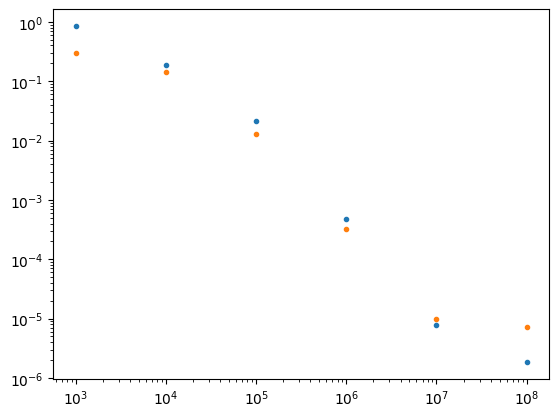

In [ ]:
plt.plot(N_lin,rel_rms_error_interp,'.')
plt.plot(N_lin,rms_rel_error_interp,'.')
plt.xscale('log')
plt.yscale('log')

([<matplotlib.axis.XTick at 0x2c79a0c7b30>,
 [Text(1000.0, 0, '$10^3 -> 10^4$'),
  Text(10000.0, 0, '$10^4 -> 10^5$'),
  Text(100000.0, 0, '$10^5 -> 10^6$'),
  Text(1000000.0, 0, '$10^6 -> 10^7$'),
  Text(10000000.0, 0, '$10^7 -> 10^8$')])

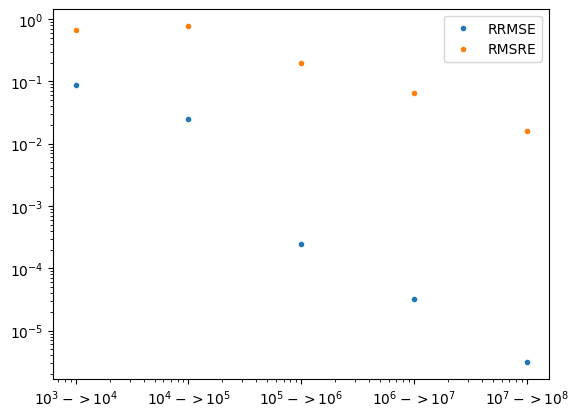

In [ ]:
plt.plot(N_lin[:-1],rel_rms_error_conv,'.',label='RRMSE')
plt.plot(N_lin[:-1],rms_rel_error_conv,'.',label='RMSRE')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xticks(N_lin[:-1],[f'$10^3 -> 10^4$',f'$10^4 -> 10^5$',f'$10^5 -> 10^6$',f'$10^6 -> 10^7$',f'$10^7 -> 10^8$'])

In [ ]:
SHG_theory_RIN_lin = SHG_RIN_spec(frequencies_lin,RIN2095_lin)

SHG_theory_RIN = interp1d(frequencies_lin, SHG_theory_RIN_lin, kind='linear', bounds_error=False, fill_value=0.0)(frequencies_log)


THG_theory_RIN_lin = THG_RIN_spec(frequencies_lin,RIN2095_lin)
THG_theory_RIN = interp1d(frequencies_lin, THG_theory_RIN_lin, kind='linear', bounds_error=False, fill_value=0.0)(frequencies_log)


# cascaded_RIN_data_theory = SFG_RIN_spec(frequencies_lin,RIN1047SHG_lin)

# cascaded_RIN_theory = SFG_RIN_spec(frequencies_lin,SHG_theory_RIN)

THG_RIN_approx_lin = approx_THG_RIN_spec(RIN2095_lin)
THG_RIN_approx = interp1d(frequencies_lin, THG_RIN_approx_lin, kind='linear', bounds_error=False, fill_value=0.0)(frequencies_log)


SFG_theory_RIN_lin = SFG_RIN_spec(frequencies_lin,RIN1970_lin, RIN1082_lin)
SFG_theory_RIN = interp1d(frequencies_lin, SFG_theory_RIN_lin, kind='linear', bounds_error=False, fill_value=0.0)(frequencies_log)


In [ ]:

RIN_int_pump = linear_to_dB(integrated_RIN(pump_freqs,pump_RIN))

RIN_int_SHG_theory = linear_to_dB(integrated_RIN(pump_freqs,SHG_theory_RIN))

RIN_int_THG_theory = linear_to_dB(integrated_RIN(pump_freqs,THG_theory_RIN))

RIN_int_SHG_data = linear_to_dB(integrated_RIN(SHG_freqs,SHG_RIN))

RIN_int_SFG_data = linear_to_dB(integrated_RIN(SFG_freqs,SFG_RIN))

RIN_int_THG_data = linear_to_dB(integrated_RIN(pump_freqs,THG_RIN))

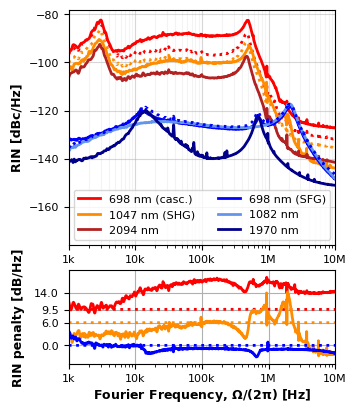

In [ ]:
fig, [axRIN,axP] = plt.subplots(nrows=2,ncols=1,figsize=(3.35,4.1),height_ratios=[5,2.]) #old figsize: figsize=(4.15,5.17)


marksize = 2
fontsize = 9
labelsize=8

# plt.plot(pump_freqs,THG_RIN_approx, 'y--',label = 'THG theory 2')


# plt.plot(SHG_freqs,cascaded_RIN_data_theory, '--',label = 'SHG + SFG uncorrelated data theory')

# plt.plot(SHG_freqs,cascaded_RIN_theory, '--',label = 'SHG + SFG uncorrelated theory')





axP.set_xlabel(r'Fourier Frequency, $\mathbf{\Omega/(2\pi)}$ [Hz]', fontweight='bold', fontsize=fontsize,labelpad=2.2)
axP.set_ylabel('RIN penalty [dB/Hz]',fontweight='bold', fontsize=fontsize,labelpad=7)

axRIN.set_ylabel('RIN [dBc/Hz]', fontweight='bold', fontsize=fontsize)

axRIN.xaxis.set_tick_params(labelsize=labelsize)
axRIN.yaxis.set_tick_params(labelsize=labelsize)
axP.xaxis.set_tick_params(labelsize=labelsize)
axP.yaxis.set_tick_params(labelsize=labelsize)



#THG
axRIN.plot(THG_freqs,linear_to_dB(THG_RIN), color='red', label='698 nm (casc.)', linewidth=marksize)

axRIN.plot(pump_freqs,linear_to_dB(THG_theory_RIN), ':', color='red', label = '_nolegend_', linewidth=marksize)

axRIN.plot(SHG_freqs,linear_to_dB(SHG_RIN), color='darkorange', label='1047 nm (SHG)', linewidth=marksize)

axRIN.plot(pump_freqs,linear_to_dB(SHG_theory_RIN),':', color='darkorange',label='_nolegend_', linewidth=marksize)

axRIN.plot(pump_freqs,linear_to_dB(pump_RIN), color='firebrick', label='2094 nm', linewidth=marksize)

#SFG
axRIN.plot(SFG_freqs,linear_to_dB(SFG_RIN), color='blue', label='698 nm (SFG)', linewidth=marksize)

axRIN.plot(SFG_pump1_freqs,linear_to_dB(SFG_pump1_RIN), color='cornflowerblue', label='1082 nm', linewidth=marksize)
axRIN.plot(SFG_pump2_freqs,linear_to_dB(SFG_pump2_RIN), color='darkblue', label='1970 nm', linewidth=marksize)

axRIN.plot(SFG_freqs,linear_to_dB(SFG_theory_RIN), ':', color='blue', label='_nolegend_', linewidth=marksize)


fig.tight_layout()

axRIN.set_xscale('log')

fig.subplots_adjust(left=0.175, right=0.97, top=0.99, bottom=0.125, hspace = 0.15)
# fig.subplots_adjust(hspace=0.15)


axRIN.set_xlim([1e3,1e7])
axRIN.set_ylim([-176,-78])

axRIN.grid(True,which='minor',alpha=0.15)
axRIN.grid(True,which='major',alpha=0.5)
# axRIN.vlines(5e5,-np.inf,np.inf)

axRIN.set_yticks(np.arange(-160,-70,20))


axRIN.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
axRIN.set_xticklabels(['1k', '10k', '100k', '1M', '10M'])


axRIN.legend(ncol=2,fontsize=labelsize,loc='lower center')
# axRIN.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_data_theory.pdf")
# axRIN.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_data_theory.svg")





axP.plot(THG_freqs,linear_to_dB(THG_RIN)-linear_to_dB(pump_RIN),color='red',label='THG', linewidth=marksize)
axP.plot(THG_freqs,linear_to_dB(THG_theory_RIN)-linear_to_dB(pump_RIN), ':', color='red',label='_nolegend_', linewidth=marksize) #shot noise for THG data present? Also fits nicely with the RIN osc. freq. peak for the amplifier, possible that coupled amplitude alters something for laser peak?


axP.plot(SHG_freqs,linear_to_dB(SHG_RIN)-linear_to_dB(pump_RIN),color='darkorange',label='SHG', linewidth=marksize)
axP.plot(SHG_freqs,linear_to_dB(SHG_theory_RIN)-linear_to_dB(pump_RIN),':',color='darkorange',label='_nolegend_', linewidth=marksize) #shot noise for SHG data present?

SFG_pump_sum_RIN = SFG_pump1_RIN + SFG_pump2_RIN

axP.plot(SFG_freqs,linear_to_dB(SFG_RIN)-linear_to_dB(SFG_pump_sum_RIN),color='blue',label='SFG', linewidth=marksize)
axP.plot(SFG_freqs,linear_to_dB(SFG_theory_RIN)-linear_to_dB(SFG_pump_sum_RIN), ':', color='blue',label='_nolegend_', linewidth=marksize)



axP.set_xscale('log')

# axP.legend(fontsize=fontsize)
# axP.xlabel('Fourier frequency [Hz]')

axP.grid()
axP.set_ylim([-5,20])
axP.set_xlim([1e3,1e7])
axP.set_yticks([0,6,9.5,14])


axP.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
axP.set_xticklabels(['1k', '10k', '100k', '1M', '10M'])



# fig.align_ylabels([axRIN,axP])


# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.pdf")
# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.svg")

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_combined.svg")#, bbox_inches='tight')

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_combined.pdf")#, bbox_inches='tight')




In [ ]:
num_values = 1000

# RIN_int_pump_values = np.linspace(-100,90,num_values) #for generating flat noise spectrum

# avg_RIN_spec_pump_values = linear_to_dB(dB_to_linear(RIN_int_pump_values)/(pump_freqs[-1]-pump_freqs[0]))

avg_RIN_spec_pump_values = np.logspace(-1,8,num_values) #Multiplied to our actual measured pump noise spectrum


num_points = len(pump_freqs)

# input_RIN_spec_values = np.ones(num_values)
# SHG_theory_RIN_spec_calc = np.ones(num_values)
# SFG_theory_RIN_spec_calc = np.ones(num_values)
# THG_theory_RIN_spec_calc = np.ones(num_values)
# SHG_approx_RIN_spec_calc = np.ones(num_values)
# SFG_approx_RIN_spec_calc = np.ones(num_values)
# THG_approx_RIN_spec_calc = np.ones(num_values)




RIN_int_pump_calc = np.ones((num_values))
RIN_int_SHG_calc = np.ones((num_values))
RIN_int_SFG_calc = np.ones((num_values))
RIN_int_THG_calc = np.ones((num_values))
RIN_int_Cascaded_calc = np.ones((num_values))

RIN_int_SHG_approx_calc = np.ones((num_values))
RIN_int_SFG_sum_p1_p_2 = np.ones((num_values))
RIN_int_THG_approx_calc = np.ones((num_values))

delta_diff_check_SHG = np.ones((num_values))
delta_diff_check_THG = np.ones((num_values))





RIN_squared_int = np.ones((num_values))

RIN_tripled_int = np.ones((num_values))

variance_offset_int = np.ones((num_values))   

variance_squared_offset_int = np.ones((num_values))   

RIN_variance_int = np.ones((num_values))   

RIN_variance_squared_int = np.ones((num_values))   





for i,avg_RIN_pump_value in enumerate(avg_RIN_spec_pump_values):
    #avg_RIN_spec_pump = np.ones((num_points))*avg_RIN_pump_value

    modified_RIN_input =  pump_RIN_lin * avg_RIN_pump_value  #Multiply RIN input spectrum with values above in linear scale and insert that as x-scale when integrated 
    
    avg_RIN_spec_pump = modified_RIN_input

    SHG_theory_RIN = SHG_RIN_spec(frequencies_lin,avg_RIN_spec_pump) #from 1/Hz to 1/Hz
    THG_theory_RIN = THG_RIN_spec(frequencies_lin,avg_RIN_spec_pump)
    cascaded_RIN_theory = SFG_RIN_spec(frequencies_lin,avg_RIN_spec_pump,SHG_theory_RIN)

    SFG_theory_RIN = SFG_RIN_spec(frequencies_lin,avg_RIN_spec_pump,avg_RIN_spec_pump)

    SHG_approx_RIN = approx_SHG_RIN_spec(avg_RIN_spec_pump)
    SFG_sum_p1_p2_RIN = avg_RIN_spec_pump + avg_RIN_spec_pump
    THG_approx_RIN = approx_THG_RIN_spec(avg_RIN_spec_pump)

    pump_int_RIN = integrated_RIN(frequencies_lin,avg_RIN_spec_pump)

    # input_RIN_spec_values[i] = avg_RIN_spec_pump[0]
    # SHG_theory_RIN_spec_calc[i] = SHG_theory_RIN[0]
    # THG_theory_RIN_spec_calc[i] = THG_theory_RIN[0]
    # SHG_approx_RIN_spec_calc[i] = SHG_approx_RIN[0]
    # THG_approx_RIN_spec_calc[i] = THG_approx_RIN[0]
 

    RIN_int_pump_calc[i] = linear_to_dB(pump_int_RIN) # sanity check

    RIN_int_SHG_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,SHG_theory_RIN) + pump_int_RIN**2) #Adding the delta function, that gives an addition of int. RIN^2. 
    RIN_int_SFG_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,SFG_theory_RIN)) #Integrated RIN: linear to linear
    RIN_int_THG_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,THG_theory_RIN) + 9 * pump_int_RIN**2) #Adding the delta function, that gives an addition of int. 9 RIN^2) 

    delta_diff_check_SHG[i] = linear_to_dB(integrated_RIN(frequencies_lin,SHG_theory_RIN))
    delta_diff_check_THG[i] = linear_to_dB(integrated_RIN(frequencies_lin,THG_theory_RIN))


    RIN_int_Cascaded_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,cascaded_RIN_theory)) 

    RIN_int_SHG_approx_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,SHG_approx_RIN))
    RIN_int_SFG_sum_p1_p_2[i] = linear_to_dB(integrated_RIN(frequencies_lin,SFG_sum_p1_p2_RIN))
    RIN_int_THG_approx_calc[i] = linear_to_dB(integrated_RIN(frequencies_lin,THG_approx_RIN))




    RIN_sq = RIN_squared(frequencies_lin,avg_RIN_spec_pump)

    RIN_tri = RIN_tripled(frequencies_lin,avg_RIN_spec_pump)

    var_off = variance_offset(frequencies_lin, avg_RIN_spec_pump)

    var_sq_off = variance_squared_offset(frequencies_lin, avg_RIN_spec_pump)

    RIN_var = RIN_variance(frequencies_lin, avg_RIN_spec_pump)

    RIN_var_sq = RIN_variance_squared(frequencies_lin, avg_RIN_spec_pump)




    RIN_squared_int[i] = linear_to_dB(integrated_RIN(frequencies_lin,RIN_sq))
    RIN_tripled_int[i] = linear_to_dB(integrated_RIN(frequencies_lin,RIN_tri))

    variance_offset_int[i] =  linear_to_dB(var_off)
    variance_squared_offset_int[i] = linear_to_dB(var_sq_off)

    RIN_variance_int[i] = linear_to_dB(integrated_RIN(frequencies_lin,RIN_var))
    RIN_variance_squared_int[i] =  linear_to_dB(integrated_RIN(frequencies_lin,RIN_var_sq))


#Comparison of terms






In [ ]:
mpl.rcParams.update({
    "legend.framealpha": 0.8,
    "legend.fancybox": True,
    "grid.color": "0.8",
    "grid.linewidth": 0.8,
})

def legend_text(s):
    return TextArea(s, textprops=dict(size=labelsize))


def legend_row(handle, label, labelsize):
    handle_length= int(2*labelsize)
    handle_height= int(0.7*labelsize)
    da = DrawingArea(handle_length, handle_height, 0, 0)
    line = Line2D(
        [0, handle_length],
        [handle_height/2]*2,
        color=handle.get_color(),
        linestyle=handle.get_linestyle(),
        linewidth=handle.get_linewidth(),
    )
    da.add_artist(line)

    txt = TextArea(label, textprops=dict(size=labelsize))
    return HPacker(children=[da, txt], align="center", pad=0, sep=6)


def equi_spaced_legend(handles,labels,labelsize):
    left_col = VPacker(children=[
        legend_row(handles[0],labels[0],labelsize,),
        legend_row(handles[1],labels[1],labelsize),
        legend_row(handles[2],labels[2],labelsize),
    ], align="left", pad=-5, sep=3)

    right_col = VPacker(children=[
        legend_row(handles[3],labels[3],labelsize),
        legend_row(handles[4],labels[4],labelsize),
        legend_row(handles[5],labels[5],labelsize),
    ], align="left", pad=-3.05, sep=6.92)  # ← different spacing

    legend_content = HPacker(
        children=[left_col, right_col],
        align="top",
        pad=0,
        sep=15
    )                                                       

    legend = AnchoredOffsetbox(
        loc="upper left",
        child=legend_content,
        frameon=True,
        borderpad=0.6
    )

    # Match native legend styling
    legend.patch.set_boxstyle("round,pad=0.4,rounding_size=0.2")
    legend.patch.set_facecolor("white")
    legend.patch.set_edgecolor("black")
    legend.patch.set_linewidth(0.8)

    legend.patch.set_alpha(mpl.rcParams["legend.framealpha"])
    legend.patch.set_edgecolor(mpl.rcParams["grid.color"])
    legend.patch.set_linewidth(mpl.rcParams["grid.linewidth"])

    return legend


def equi_spaced_legend_sup(handles,labels,labelsize):
    left_col = VPacker(children=[
        legend_row(handles[0],labels[0],labelsize,),
        legend_row(handles[1],labels[1],labelsize),
        legend_row(handles[2],labels[2],labelsize),
        legend_row(handles[3],labels[3],labelsize),
    ], align="left", pad=-6.5, sep=2.5)

    right_col = VPacker(children=[
        legend_row(handles[4],labels[4],labelsize),
        legend_row(handles[5],labels[5],labelsize),
        legend_row(handles[6],labels[6],labelsize),
    ], align="left", pad=-4.52, sep=6.4)  # ← different spacing

    legend_content = HPacker(
        children=[left_col, right_col],
        align="top",
        pad=0,
        sep=15
    )                                                       

    legend = AnchoredOffsetbox(
        loc="upper left",
        child=legend_content,
        frameon=True,
        borderpad=0.6
    )

    # Match native legend styling
    legend.patch.set_boxstyle("round,pad=0.4,rounding_size=0.2")
    legend.patch.set_facecolor("white")
    legend.patch.set_edgecolor("black")
    legend.patch.set_linewidth(0.8)

    legend.patch.set_alpha(mpl.rcParams["legend.framealpha"])
    legend.patch.set_edgecolor(mpl.rcParams["grid.color"])
    legend.patch.set_linewidth(mpl.rcParams["grid.linewidth"])

    return legend

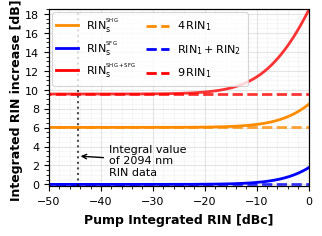

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



fig, ax = plt.subplots(figsize=(3.35,2.3))

# plt = brokenaxes(ylims=((-5e-7,1e-5),(5,17)),hspace=0.15,height_ratios=(1,0.15))


# plt.plot(RIN_int_pump_values,RIN_int_pump_calc-RIN_int_pump_values, label='Pump', color = 'brown',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_SHG_calc-RIN_int_pump_values, label=r'$\mathrm{RIN}_\mathrm{s}^{^\mathrm{SHG}}$', color = 'darkorange',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_SFG_calc-RIN_int_SFG_sum_p1_p_2, label=r'$\mathrm{RIN}_\mathrm{s}^{^\mathrm{SFG}}$', color = 'blue',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_THG_calc-RIN_int_pump_values, label=r'$\mathrm{RIN}_\mathrm{s}^{^{\mathrm{SHG}+\mathrm{SFG}}}$', color = 'red', alpha = 0.8, linewidth=marksize)
# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc-RIN_int_pump_values, ls='--', color = 'darkorange',  label=r'$4\,\mathrm{RIN}_1 $', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2-RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2 $', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc-RIN_int_pump_values, ls='--', color = 'red', label=r'$9\,\mathrm{RIN}_1 $', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'

# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


marksize = 2
fontsize = 9
labelsize =8
handles, labels = ax.get_legend_handles_labels()
# leg1 = ax.legend(handles[:3], labels[:3], loc='upper left', labelspacing=0.5)
# ax.add_artist(leg1)
# leg2 = ax.legend(handles[3:], labels[3:], loc='upper left', 
#                  bbox_to_anchor=(0.5, 1), labelspacing=2)
legend = equi_spaced_legend(handles, labels, labelsize)

ax.add_artist(legend)


# plt.legend(ncol=2,loc='upper left',fontsize=labelsize, labelspacing=0.2)


# plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

ax.grid()
ax.set_xlim([-50,0])
ax.set_ylim([-2e-1,18.5])
# plt.ylim([-.0000001,.00001])
ax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=5)
ax.set_ylabel('Integrated RIN increase [dB]',fontweight='bold', fontsize=fontsize, labelpad=5)
ax.yaxis.set_label_coords(-0.1,0.49)


# for ax in bax.axs:
ax.minorticks_on()
ax.grid(True,which='minor',alpha=0.15)
ax.grid(True,which='major',alpha=0.5)

ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.7)

ax.tick_params(axis='x',labelsize=labelsize)
ax.tick_params(axis='y',labelsize=labelsize)

# ax.tick_params(axis='x',which='both',bottom=False,top=False,labelbottom=False)


current_ticks = plt.xticks()[0]  # Get tick locations
current_labels = [label.get_text() for label in plt.xticks()[1]]

# ax.axs[1].set_yticks([0,1e-5])
# ax.axs[1].set_yticklabels(['0', '1e-5'])

ax.set_yticks([0,2,4,6,8,10,12,14,16,18])
ax.set_yticklabels(['0','2','4','6','8','10','12','14','16','18'])

ax.annotate('Integral value\nof 2094 nm\nRIN data', xy=(RIN_int_pump, 3),xytext=(RIN_int_pump+6, 1), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
# ax.axs[0].annotate('', xy=(RIN_int_pump, 5.5), xytext=(RIN_int_pump+5.5, 5), arrowprops=dict(arrowstyle='->', color='k', lw=1), fontsize=labelsize)

# fig.tight_layout()

# Add after all plotting commands (just before savefig)
# rect = patches.Rectangle((0, 0), 1, 1,
#                              transform=bax.fig.transFigure,
#                         fill=False, color='black', linewidth=1)
# bax.fig.patches.append(rect)

# for ax in bax.axs:
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_linewidth(0.8)  # adjust thickness if you want

# # Draw a single outer frame around the entire brokenaxes area
# bbox = bax.figbox()  # coordinates of the brokenaxes in figure units
# fig = bax.fig
# rect = plt.Rectangle(
#     (bbox.x0, bbox.y0),
#     bbox.width,
#     bbox.height,
#     transform=fig.transFigure,
#     color='black',
#     fill=False,
#     lw=0.8
# )
# fig.patches.append(rect)





# ensure positions are up-to-date
# fig.tight_layout()
fig.canvas.draw()

# get the positions (Bbox) of all internal axes (in figure coords)
bboxes = [ax.get_position()]

# compute union bbox (min x0,y0 and max x1,y1)
x0 = min(b.x0 for b in bboxes)
y0 = min(b.y0 for b in bboxes)
x1 = max(b.x1 for b in bboxes)
y1 = max(b.y1 for b in bboxes)

# optional padding in figure coordinates (tiny fraction)
pad = 0.008

# draw rectangle in figure coordinates
rect = plt.Rectangle(
    (x0, y0),
    (x1 - x0),
    (y1 - y0),
    transform=fig.transFigure,
    fill=False,
    linewidth=0.8,
    edgecolor='black',
    zorder=10
)
fig.patches.append(rect)



# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + [r'$\frac{\sigma_1^2}{\overline{I}_1^2}$']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# bax.set_xticks(final_ticks, final_labels)


plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Int_RIN_spectrum_approx_vs_higher_order.pdf",bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Int_RIN_spectrum_approx_vs_higher_order.svg",bbox_inches='tight')



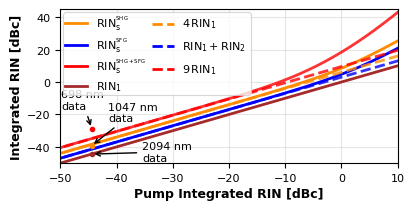

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



fig, ax = plt.subplots(figsize=(4.35,2))


ax.plot(RIN_int_pump_values,RIN_int_SHG_calc, label=r'$\mathrm{RIN}_\mathrm{s}^{^{\mathrm{SHG}}}$', color = 'darkorange',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label=r'$\mathrm{RIN}_\mathrm{s}^{^\mathrm{SFG}}$', color = 'blue',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_THG_calc, label=r'$\mathrm{RIN}_\mathrm{s}^{^{\mathrm{SHG}+\mathrm{SFG}}}$', color = 'red', alpha = 0.8, linewidth=marksize)
ax.plot(RIN_int_pump_values,RIN_int_pump_calc, label=r'$\mathrm{RIN}_1$', color = 'brown',linewidth=marksize)

# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'


# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


marksize = 2
fontsize = 9
labelsize =8
handles, labels = ax.get_legend_handles_labels()

legend = equi_spaced_legend_sup(handles, labels, labelsize)
ax.add_artist(legend)

# ax.legend(ncol=2,loc='upper left',fontsize=labelsize, columnspacing = 0.8)

# plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

ax.grid()
ax.set_xlim([-50,10])
ax.set_ylim([-50,45])
# plt.ylim([-.0000001,.00001])
ax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=3)
ax.set_ylabel('Integrated RIN [dBc]',fontweight='bold', fontsize=fontsize, labelpad=3)

# ax.minorticks_on()
ax.grid(True,which='minor',alpha=0.15)
ax.grid(True,which='major',alpha=0.5)

# ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.4)

ax.tick_params(axis='x',labelsize=labelsize)
ax.tick_params(axis='y',labelsize=labelsize)



ax.annotate('2094 nm\ndata', xy=(RIN_int_pump, RIN_int_pump),xytext=(RIN_int_pump+9, -48.5), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
ax.annotate('1047 nm\ndata', xy=(RIN_int_pump, RIN_int_SHG_data),xytext=(RIN_int_pump+3, RIN_int_SHG_data+15), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)

ax.annotate('698 nm\ndata', xy=(RIN_int_pump, RIN_int_THG_data),xytext=(RIN_int_pump-5.4, RIN_int_THG_data+12), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)



plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange',linewidth=marksize)

plt.plot(RIN_int_pump,RIN_int_SFG_data,'.',color='blue',linewidth=marksize)

plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red',linewidth=marksize)


# inset_ax = inset_axes(ax, width="30%",height="30%",loc='lower left',bbox_to_anchor=(0.67,0.08,.9,.9),bbox_transform=ax.transAxes)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='_nolegend_', color = 'blue',linewidth=marksize)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = '_nolegend_', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'
# inset_ax.set_ylim([3.010257,3.0104])
# inset_ax.set_xlim([0,1e-4])
# inset_ax.grid()


# current_ticks = plt.xticks()[0]  # Get tick locations
# current_labels = [label.get_text() for label in plt.xticks()[1]]
# 
# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + ['2094\nnm\nRIN\ndata']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# ax.set_xticks(final_ticks, final_labels)


plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.pdf",bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.svg",bbox_inches='tight')



In [ ]:
ghgfdjhkl

: 

: 

: 

: 

In [ ]:
RIN_tripled_int

array([-1.63330457e+02, -1.63060187e+02, -1.62789917e+02, -1.62519647e+02,
       -1.62249376e+02, -1.61979106e+02, -1.61708836e+02, -1.61438566e+02,
       -1.61168295e+02, -1.60898025e+02, -1.60627755e+02, -1.60357484e+02,
       -1.60087214e+02, -1.59816944e+02, -1.59546674e+02, -1.59276403e+02,
       -1.59006133e+02, -1.58735863e+02, -1.58465593e+02, -1.58195322e+02,
       -1.57925052e+02, -1.57654782e+02, -1.57384511e+02, -1.57114241e+02,
       -1.56843971e+02, -1.56573701e+02, -1.56303430e+02, -1.56033160e+02,
       -1.55762890e+02, -1.55492620e+02, -1.55222349e+02, -1.54952079e+02,
       -1.54681809e+02, -1.54411538e+02, -1.54141268e+02, -1.53870998e+02,
       -1.53600728e+02, -1.53330457e+02, -1.53060187e+02, -1.52789917e+02,
       -1.52519647e+02, -1.52249376e+02, -1.51979106e+02, -1.51708836e+02,
       -1.51438566e+02, -1.51168295e+02, -1.50898025e+02, -1.50627755e+02,
       -1.50357484e+02, -1.50087214e+02, -1.49816944e+02, -1.49546674e+02,
       -1.49276403e+02, -

: 

: 

: 

: 

-163.33045739718983
-155.5489448933534
-150.77773234615677
-148.5592448499932
-145.5489448933534
-142.53864493671358


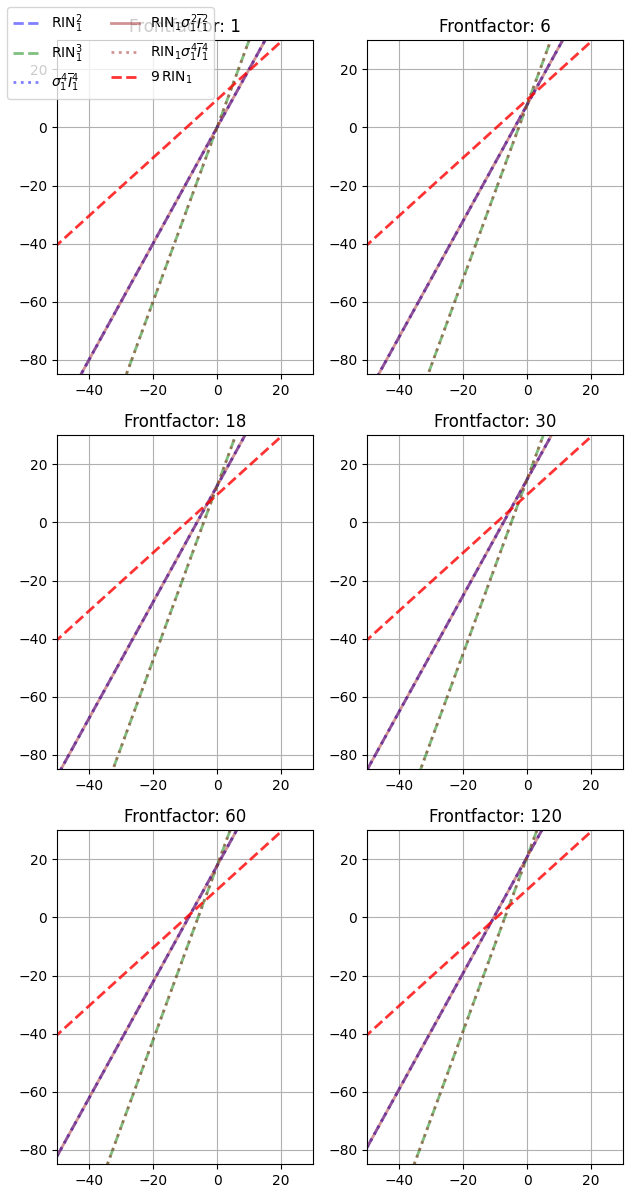

: 

: 

: 

: 

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



fig, axes = plt.subplots(3,2,figsize=(6.35,12))


mult = [4,9]

frontfac = [1,6,18,30,60,120]

for i, ax in enumerate(axes.flatten()):

        RIN_comp = 0*mult[1]*dB_to_linear(RIN_int_pump_values)

        RIN_sq = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_squared_int)) 

        RIN_tri = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_tripled_int))
        print(RIN_tri[0])

        RIN_var_off = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(variance_offset_int)) 

        RIN_var_sq_off = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(variance_squared_offset_int)) 

        RIN_RIN_var = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_variance_int)) 

        RIN_RIN_var_sq = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_variance_squared_int))


        ax.plot(RIN_int_pump_values,  RIN_sq , color='blue',ls='--', linewidth=marksize, label=r'$\mathrm{RIN}_1^2$', alpha=0.5)

        ax.plot(RIN_int_pump_values, RIN_tri, color='green', ls='--', linewidth=marksize, label=r'$\mathrm{RIN}_1^3$', alpha=0.5)

        # ax.plot(RIN_int_pump_values,RIN_var_off, color='blue', ls='-', linewidth=marksize, label=r'$\sigma_1^2 \overline{I}_1^2$')

        ax.plot(RIN_int_pump_values,RIN_var_sq_off, color='blue', ls=':', alpha = 0.5, linewidth=marksize, label=r'$\sigma_1^4 \overline{I}_1^4$')

        ax.plot(RIN_int_pump_values,RIN_RIN_var,color='brown', ls='-', linewidth=marksize, label=r'$\mathrm{RIN}_1 \sigma_1^2 \overline{I}_1^2$',alpha=0.5)

        ax.plot(RIN_int_pump_values,RIN_RIN_var_sq,color='brown', ls=':', linewidth=marksize, label=r'$\mathrm{RIN}_1 \sigma_1^4 \overline{I}_1^4$', alpha=0.5)

        # ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

        ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'

        ax.set_xlim(-50,30)
        ax.set_ylim(-85,30)
        ax.grid()
        ax.set_title(f'Frontfactor: {frontfac[i]}')


# Create a single legend for the entire figure
handles, labels = ax.get_legend_handles_labels()  # Get from last subplot (or any)
fig.legend(handles, labels, loc='upper left', ncol=2)  # Adjust location & columns

plt.tight_layout()
plt.show()


# ax.plot(RIN_int_pump_values,RIN_int_SHG_calc, label='SHG', color = 'darkorange',linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='SFG', color = 'blue',linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_THG_calc, label='THG', color = 'red', alpha = 0.8, linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_pump_calc, label='Pump', color = 'brown',linewidth=marksize)

# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



# ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

# ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


# ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'


# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


# marksize = 2
# fontsize = 9
# labelsize =8
# ax.legend(ncol=2,loc='upper left',fontsize=labelsize, columnspacing = 0.8)

# # plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# # plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# # plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

# ax.grid()
# ax.set_xlim([-50,10])
# ax.set_ylim([-50,42])
# # plt.ylim([-.0000001,.00001])
# ax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=3)
# ax.set_ylabel('Integrated RIN [dBc]',fontweight='bold', fontsize=fontsize, labelpad=3)

# # ax.minorticks_on()
# ax.grid(True,which='minor',alpha=0.15)
# ax.grid(True,which='major',alpha=0.5)

# # ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.4)

# ax.tick_params(axis='x',labelsize=labelsize)
# ax.tick_params(axis='y',labelsize=labelsize)



# ax.annotate('2094 nm\ndata', xy=(RIN_int_pump, RIN_int_pump),xytext=(RIN_int_pump+9, -48.5), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
# .5
# ax.annotate('1047 nm\ndata', xy=(RIN_int_pump, RIN_int_SHG_data),xytext=(RIN_int_pump+3, RIN_int_SHG_data+15), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)

# ax.annotate('698 nm\ndata', xy=(RIN_int_pump, RIN_int_THG_data),xytext=(RIN_int_pump-5.5, RIN_int_THG_data+13), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)




# inset_ax = inset_axes(ax, width="30%",height="30%",loc='lower left',bbox_to_anchor=(0.67,0.08,.9,.9),bbox_transform=ax.transAxes)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='_nolegend_', color = 'blue',linewidth=marksize)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = '_nolegend_', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'
# inset_ax.set_ylim([3.010257,3.0104])
# inset_ax.set_xlim([0,1e-4])
# inset_ax.grid()


# current_ticks = plt.xticks()[0]  # Get tick locations
# current_labels = [label.get_text() for label in plt.xticks()[1]]
# 
# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + ['2094\nnm\nRIN\ndata']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# ax.set_xticks(final_ticks, final_labels)


# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.pdf")#,bbox_inches='tight')
# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.svg")#,bbox_inches='tight')



In [ ]:
num_plots = 5
input_binned_RIN_spec_powers =  np.logspace(-18,10,int(1e4)) #in linear units
int_RIN_values = np.logspace(-2.5,0,num_plots)


    
SHG_binned_RIN_spec_powers = SHG_RIN_spec(input_binned_RIN_spec_powers) #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in 1/Hz

SHG_approx_binned_RIN_spec_powers = approx_SHG_RIN_spec(input_binned_RIN_spec_powers)
THG_approx_binned_RIN_spec_powers = approx_THG_RIN_spec(input_binned_RIN_spec_powers)


plt.figure()
plt.plot(input_binned_RIN_spec_powers,SHG_binned_RIN_spec_powers, label='SHG', color = 'darkorange',linewidth=marksize)


plt.plot(input_binned_RIN_spec_powers,SHG_approx_binned_RIN_spec_powers, ls='--', color = 'darkorange', label='App. SHG', alpha = 0.8, linewidth=marksize)
plt.plot(input_binned_RIN_spec_powers,THG_approx_binned_RIN_spec_powers, ls='--', color = 'red', label='App. THG', alpha = 0.8, linewidth=marksize)


THG_binned_RIN_spec_powers = [[]]*num_plots

for i,int_RIN in enumerate(int_RIN_values):
    THG_binned_RIN_spec_powers[i] = THG_RIN_spec_var(input_binned_RIN_spec_powers,int_RIN)

    plt.plot(input_binned_RIN_spec_powers,THG_binned_RIN_spec_powers[i], label=f'THG [{int_RIN:.0f}]', alpha = 0.8, linewidth=marksize)





plt.grid()
plt.xlim([-50,0])
plt.ylim([-40,20])
plt.xlabel('Pump RIN [dBc/Hz]')
plt.ylabel('RIN [dBc/Hz]')
plt.legend()

TypeError: SHG_RIN_spec() missing 1 required positional argument: 'RIN_pump'

: 

: 

: 

: 